In [2]:
import pandas as pd

df_raw = pd.read_csv(r"C:\Users\TechTroniX\Videos\hr-attrition-analysis\WA_Fn-UseC_-HR-Employee-Attrition.csv")

df_raw.to_csv(r"C:\Users\TechTroniX\Videos\hr-attrition-analysis\hr_raw.csv", index=False)

print("Shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())
print("\nInfo:")
print(df_raw.info())
print("\nMissing values:")
print(df_raw.isnull().sum())
print("\nAttrition distribution:")
print(df_raw['Attrition'].value_counts())
print("\nAttrition rate:", f"{(df_raw['Attrition']=='Yes').mean()*100:.1f}%")

Shape: (1470, 35)

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel    

In [3]:
df = df_raw.copy()

df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])

df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)

satisfaction_map = {1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very High'}
df['JobSatisfactionLabel'] = df['JobSatisfaction'].map(satisfaction_map)
df['EnvironmentSatisfactionLabel'] = df['EnvironmentSatisfaction'].map(satisfaction_map)
df['WorkLifeBalanceLabel'] = df['WorkLifeBalance'].map(satisfaction_map)

df.to_csv(r"C:\Users\TechTroniX\Videos\hr-attrition-analysis\hr_clean.csv", index=False)

print("Shape after cleaning:", df.shape)
print("\nColumns removed: EmployeeCount, Over18, StandardHours")
print("New columns added: AttritionFlag, JobSatisfactionLabel, EnvironmentSatisfactionLabel, WorkLifeBalanceLabel")
print("\nClean file saved: hr_clean.csv")
print("\nSample of new columns:")
print(df[['Attrition', 'AttritionFlag', 'JobSatisfactionLabel', 'WorkLifeBalanceLabel']].head())

Shape after cleaning: (1470, 36)

Columns removed: EmployeeCount, Over18, StandardHours
New columns added: AttritionFlag, JobSatisfactionLabel, EnvironmentSatisfactionLabel, WorkLifeBalanceLabel

Clean file saved: hr_clean.csv

Sample of new columns:
  Attrition  AttritionFlag JobSatisfactionLabel WorkLifeBalanceLabel
0       Yes              1            Very High                  Low
1        No              0               Medium                 High
2       Yes              1                 High                 High
3        No              0                 High                 High
4        No              0               Medium                 High


In [4]:
print("=== Attrition by Department ===")
print((df.groupby('Department')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Attrition by JobRole ===")
print((df.groupby('JobRole')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Attrition by OverTime ===")
print((df.groupby('OverTime')['AttritionFlag'].mean()*100).round(1))

print("\n=== Attrition by MaritalStatus ===")
print((df.groupby('MaritalStatus')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Attrition by BusinessTravel ===")
print((df.groupby('BusinessTravel')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Attrition by JobSatisfaction ===")
print((df.groupby('JobSatisfactionLabel')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== Attrition by WorkLifeBalance ===")
print((df.groupby('WorkLifeBalanceLabel')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False))

print("\n=== MonthlyIncome: Left vs Stayed ===")
print(df.groupby('Attrition')['MonthlyIncome'].mean().round(0))

print("\n=== Age: Left vs Stayed ===")
print(df.groupby('Attrition')['Age'].mean().round(1))

print("\n=== YearsAtCompany: Left vs Stayed ===")
print(df.groupby('Attrition')['YearsAtCompany'].mean().round(1))

=== Attrition by Department ===
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: AttritionFlag, dtype: float64

=== Attrition by JobRole ===
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Healthcare Representative     6.9
Manufacturing Director        6.9
Manager                       4.9
Research Director             2.5
Name: AttritionFlag, dtype: float64

=== Attrition by OverTime ===
OverTime
No     10.4
Yes    30.5
Name: AttritionFlag, dtype: float64

=== Attrition by MaritalStatus ===
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1
Name: AttritionFlag, dtype: float64

=== Attrition by BusinessTravel ===
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0
Name: AttritionFlag, dtype: float64

=== Attrition by JobSatisfaction ===
JobSati

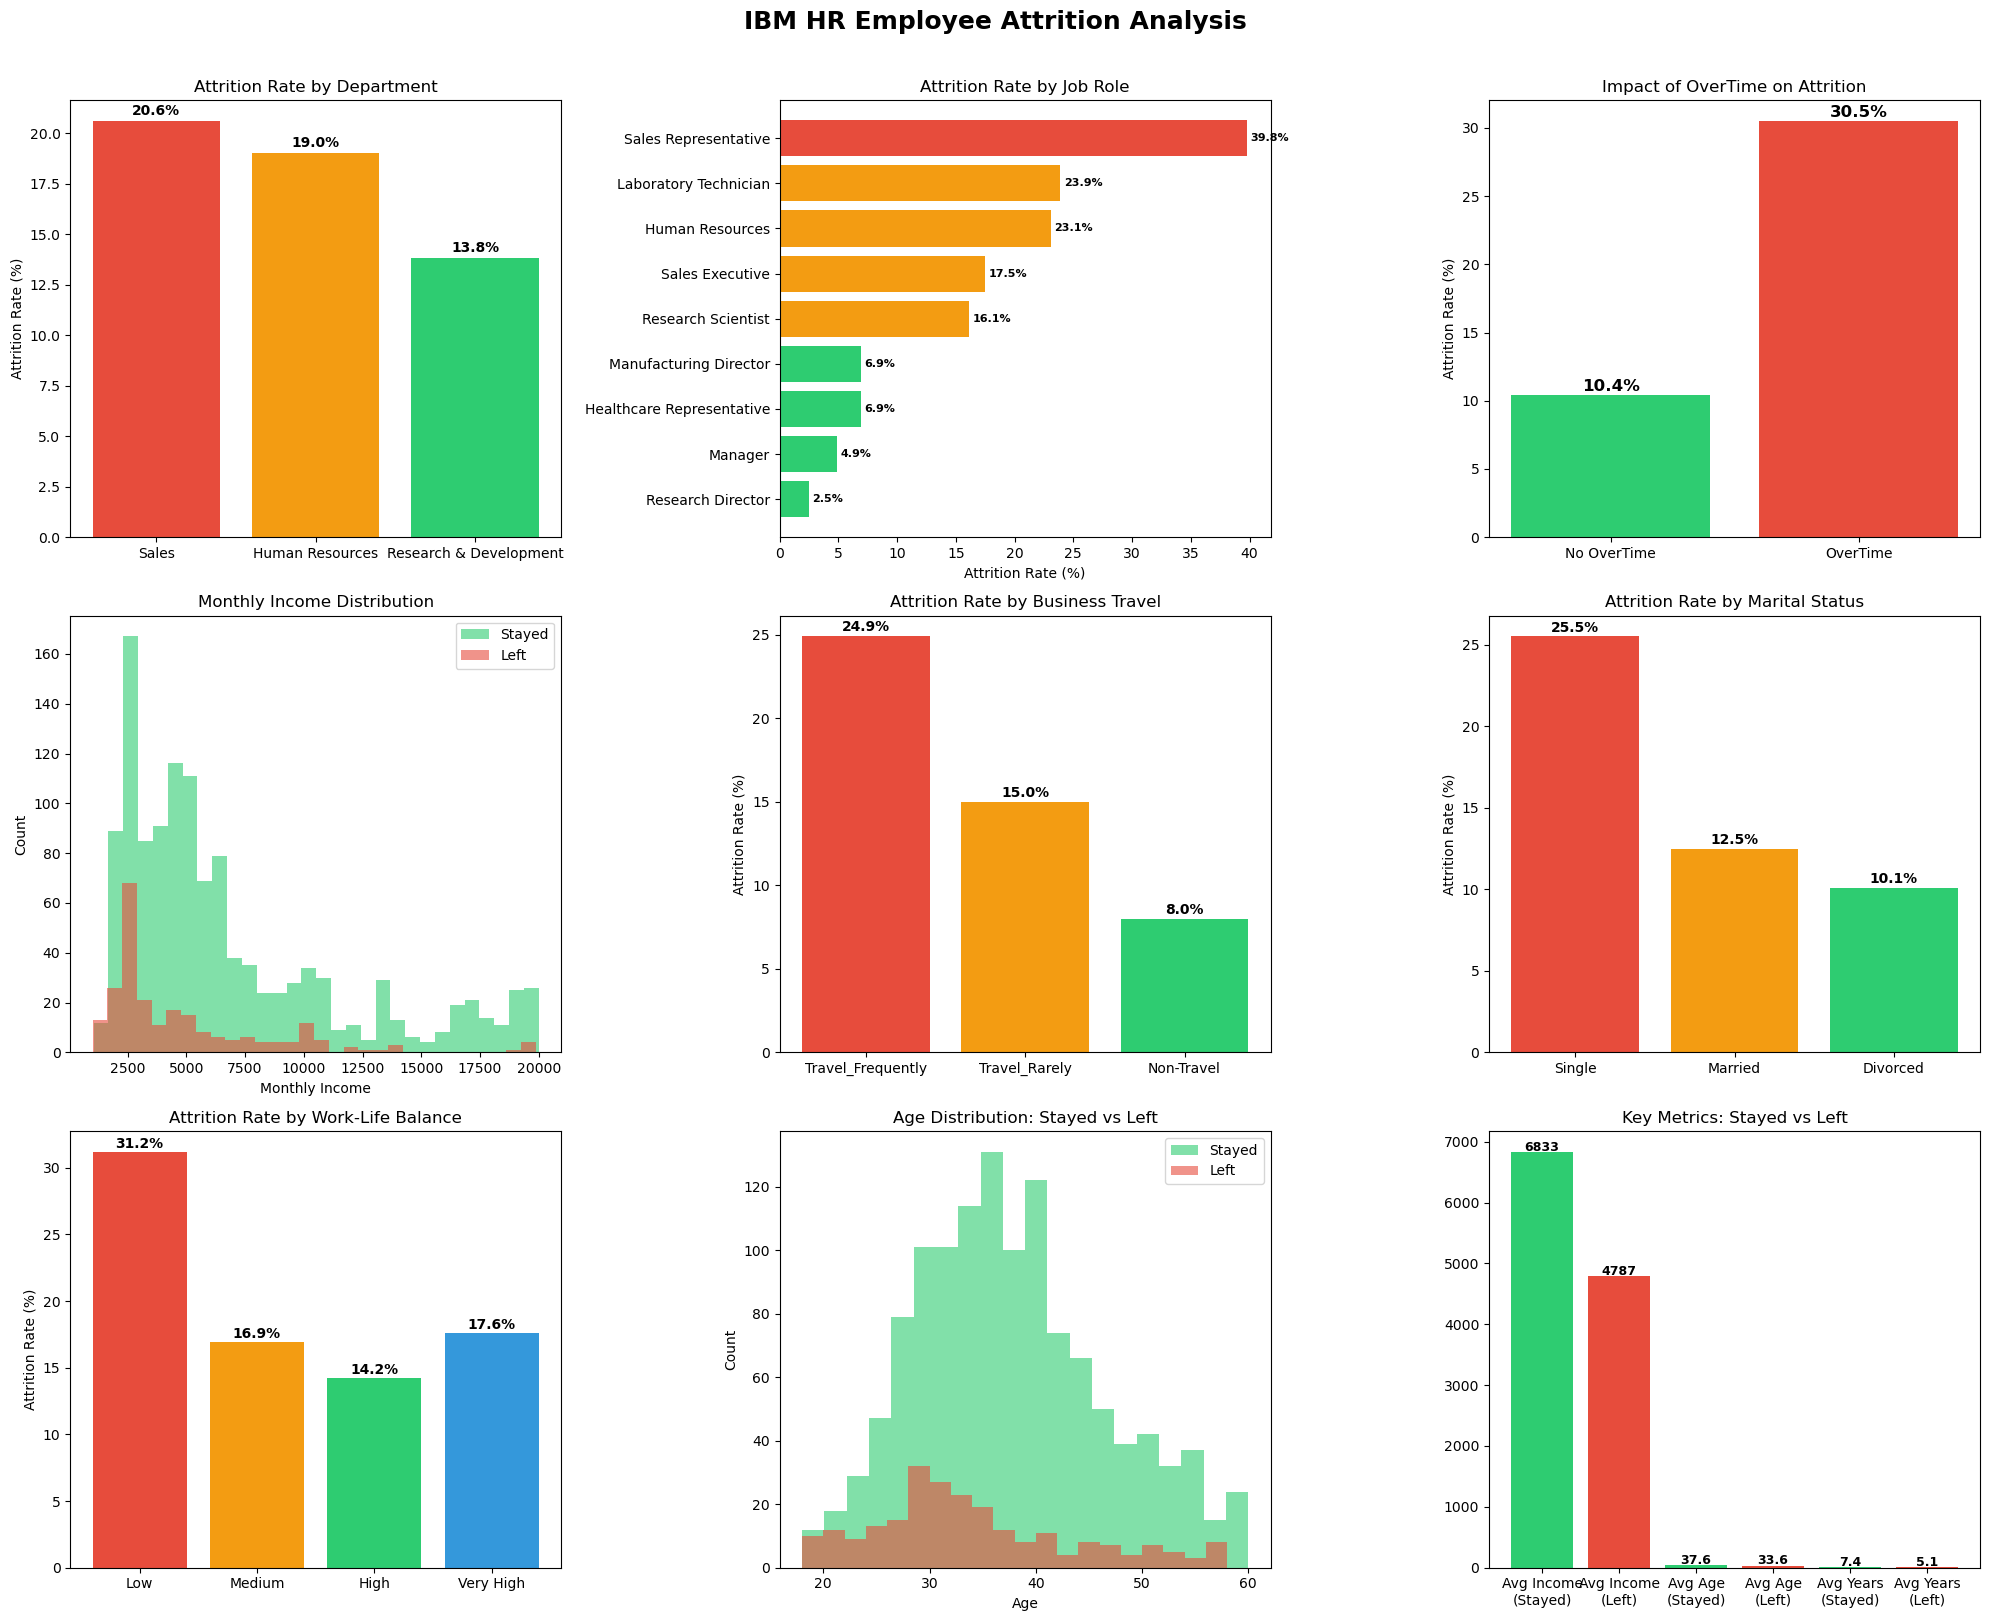

Saved successfully.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('IBM HR Employee Attrition Analysis', fontsize=18, fontweight='bold', y=1.01)

dept = (df.groupby('Department')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False)
axes[0,0].bar(dept.index, dept.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[0,0].set_title('Attrition Rate by Department')
axes[0,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(dept.values):
    axes[0,0].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')

role = (df.groupby('JobRole')['AttritionFlag'].mean()*100).round(1).sort_values()
colors_role = ['#2ecc71' if v < 15 else '#f39c12' if v < 25 else '#e74c3c' for v in role.values]
axes[0,1].barh(role.index, role.values, color=colors_role)
axes[0,1].set_title('Attrition Rate by Job Role')
axes[0,1].set_xlabel('Attrition Rate (%)')
for i, v in enumerate(role.values):
    axes[0,1].text(v+0.3, i, f'{v}%', va='center', fontweight='bold', fontsize=8)

ot = (df.groupby('OverTime')['AttritionFlag'].mean()*100).round(1)
axes[0,2].bar(['No OverTime', 'OverTime'], ot.values, color=['#2ecc71','#e74c3c'])
axes[0,2].set_title('Impact of OverTime on Attrition')
axes[0,2].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(ot.values):
    axes[0,2].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold', fontsize=12)

income_no = df[df['Attrition']=='No']['MonthlyIncome']
income_yes = df[df['Attrition']=='Yes']['MonthlyIncome']
axes[1,0].hist(income_no, bins=30, alpha=0.6, color='#2ecc71', label='Stayed')
axes[1,0].hist(income_yes, bins=30, alpha=0.6, color='#e74c3c', label='Left')
axes[1,0].set_title('Monthly Income Distribution')
axes[1,0].set_xlabel('Monthly Income')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

travel = (df.groupby('BusinessTravel')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False)
axes[1,1].bar(travel.index, travel.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,1].set_title('Attrition Rate by Business Travel')
axes[1,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(travel.values):
    axes[1,1].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')

marital = (df.groupby('MaritalStatus')['AttritionFlag'].mean()*100).round(1).sort_values(ascending=False)
axes[1,2].bar(marital.index, marital.values, color=['#e74c3c','#f39c12','#2ecc71'])
axes[1,2].set_title('Attrition Rate by Marital Status')
axes[1,2].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(marital.values):
    axes[1,2].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')

wlb_order = ['Low', 'Medium', 'High', 'Very High']
wlb = (df.groupby('WorkLifeBalanceLabel')['AttritionFlag'].mean()*100).round(1).reindex(wlb_order)
axes[2,0].bar(wlb.index, wlb.values, color=['#e74c3c','#f39c12','#2ecc71','#3498db'])
axes[2,0].set_title('Attrition Rate by Work-Life Balance')
axes[2,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(wlb.values):
    axes[2,0].text(i, v+0.3, f'{v}%', ha='center', fontweight='bold')

age_no = df[df['Attrition']=='No']['Age']
age_yes = df[df['Attrition']=='Yes']['Age']
axes[2,1].hist(age_no, bins=20, alpha=0.6, color='#2ecc71', label='Stayed')
axes[2,1].hist(age_yes, bins=20, alpha=0.6, color='#e74c3c', label='Left')
axes[2,1].set_title('Age Distribution: Stayed vs Left')
axes[2,1].set_xlabel('Age')
axes[2,1].set_ylabel('Count')
axes[2,1].legend()

metrics = ['Avg Income\n(Stayed)', 'Avg Income\n(Left)', 'Avg Age\n(Stayed)', 'Avg Age\n(Left)', 'Avg Years\n(Stayed)', 'Avg Years\n(Left)']
values = [6833, 4787, 37.6, 33.6, 7.4, 5.1]
colors_m = ['#2ecc71','#e74c3c','#2ecc71','#e74c3c','#2ecc71','#e74c3c']
axes[2,2].bar(metrics, values, color=colors_m)
axes[2,2].set_title('Key Metrics: Stayed vs Left')
for i, v in enumerate(values):
    axes[2,2].text(i, v+20, f'{v}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(r"C:\Users\TechTroniX\Videos\hr-attrition-analysis\hr_attrition_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved successfully.")

In [6]:
report = """
HR EMPLOYEE ATTRITION ANALYSIS REPORT
IBM HR Analytics Dataset
======================================

DATASET OVERVIEW
- Total Employees: 1,470
- Employees Who Left: 237
- Overall Attrition Rate: 16.1%

KEY FINDINGS
============

1. OVERTIME IS THE STRONGEST DRIVER
   - Employees with OverTime: 30.5% attrition
   - Employees without OverTime: 10.4% attrition
   - Employees doing overtime are 3x more likely to leave.

2. JOB ROLE MATTERS
   - Sales Representatives: 39.8% (highest risk)
   - Laboratory Technicians: 23.9%
   - Research Directors: 2.5% (lowest risk)

3. COMPENSATION GAP
   - Average income of employees who left: $4,787/month
   - Average income of employees who stayed: $6,833/month
   - Employees who left earned $2,046 less per month on average.

4. BUSINESS TRAVEL INCREASES RISK
   - Frequent travelers: 24.9% attrition
   - Non-travelers: 8.0% attrition

5. WORK-LIFE BALANCE IS CRITICAL
   - Poor work-life balance: 31.2% attrition
   - Good work-life balance: 14.2% attrition

6. YOUNGER EMPLOYEES LEAVE EARLIER
   - Average age of employees who left: 33.6 years
   - Average age of employees who stayed: 37.6 years
   - Average tenure of employees who left: 5.1 years vs 7.4 years

BUSINESS RECOMMENDATIONS
========================
1. Reduce mandatory overtime, especially in Sales and Lab roles.
2. Review compensation for high-risk roles (Sales Representatives).
3. Introduce flexible travel policies for frequent travelers.
4. Implement work-life balance programs targeting younger employees.
5. Create early career development paths to retain junior employees.

TOOLS USED
==========
Python, Pandas, Matplotlib
"""

with open(r"C:\Users\TechTroniX\Videos\hr-attrition-analysis\hr_attrition_report.txt", "w") as f:
    f.write(report)

print("Report saved successfully.")
print("\nProject files summary:")
print("1. hr_raw.csv          — original dataset")
print("2. hr_clean.csv        — cleaned dataset")
print("3. hr_analysis.ipynb   — full analysis notebook")
print("4. hr_attrition_analysis.png  — visualizations")
print("5. hr_attrition_report.txt    — findings report")

Report saved successfully.

Project files summary:
1. hr_raw.csv          — original dataset
2. hr_clean.csv        — cleaned dataset
3. hr_analysis.ipynb   — full analysis notebook
4. hr_attrition_analysis.png  — visualizations
5. hr_attrition_report.txt    — findings report
